# Clean Datasets

Now that we found data leakage and duplicates, it's time to clean these datasets by copying only the files we want to keep (and renaming them in the case of the validation dataset).

In [5]:
from pathlib import Path
import shutil
import matplotlib.pyplot as plt
from PIL import Image

In [12]:
with open('val_remove_paths.txt', 'r') as f:
    val_remove_paths = f.read().splitlines()

In [13]:
val_remove_paths

['..\\data\\valid\\images\\imagess_800.jpg',
 '..\\data\\valid\\images\\imagess_836.jpg',
 '..\\data\\valid\\images\\image_588.jpg',
 '..\\data\\valid\\images\\image_594.jpg',
 '..\\data\\valid\\images\\image_595.jpg',
 '..\\data\\valid\\images\\image_610.jpg',
 '..\\data\\valid\\images\\image_625.jpg',
 '..\\data\\valid\\images\\image_626.jpg',
 '..\\data\\valid\\images\\image_630.jpg',
 '..\\data\\valid\\images\\image_634.jpg',
 '..\\data\\valid\\images\\image_639.jpg',
 '..\\data\\valid\\images\\image_640.jpg',
 '..\\data\\valid\\images\\image_643.jpg',
 '..\\data\\valid\\images\\image_648.jpg',
 '..\\data\\valid\\images\\image_650.jpg',
 '..\\data\\valid\\images\\image_652.jpg',
 '..\\data\\valid\\images\\image_220.png',
 '..\\data\\valid\\images\\imagess_773.jpg',
 '..\\data\\valid\\images\\image_008.png',
 '..\\data\\valid\\images\\image_175.png',
 '..\\data\\valid\\images\\image_180.png',
 '..\\data\\valid\\images\\image_184.png',
 '..\\data\\valid\\images\\image_183.png',
 '..\

In [14]:
labels_dir = "../data/valid/labels/"
images_dir = "../data/valid/images/"

In [15]:
labels_path = Path(labels_dir)
images_path = Path(images_dir)

In [16]:
all_images = sorted(list(images_path.glob("*.jpg")) + list(images_path.glob("*.png")))
len(all_images)

1089

In [17]:
test_image = all_images[0]
test_image

WindowsPath('../data/valid/images/image_001.png')

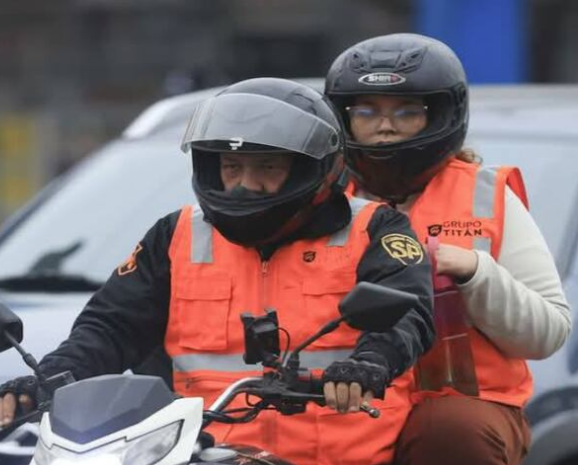

In [18]:
val_img = Image.open(test_image)
val_img

In [19]:
remove_paths = [Path(img) for img in val_remove_paths]

In [22]:
count = 0
for img in (remove_paths):
    if img.exists():
        count += 1
print(f"Images that exist: {count} out of {len(remove_paths)}")

Images that exist: 25 out of 25


In [23]:
new_images_path = Path("../data/clean_valid/images/")
new_labels_path = Path("../data/clean_valid/labels/")

In [25]:
new_labels_path.exists()

True

In [26]:
labels_class_file = labels_path / "classes.txt"

In [ ]:
# copy classes.txt from labels_dir to new_labels_path
shutil.copy(labels_class_file, new_labels_path / "classes.txt")

WindowsPath('../data/clean_valid/labels/classes.txt')

In [29]:
images_to_rename_and_copy = [img for img in all_images if img not in remove_paths]

In [30]:
len(images_to_rename_and_copy)

1064

In [31]:
images_to_rename_and_copy[:10]

[WindowsPath('../data/valid/images/image_001.png'),
 WindowsPath('../data/valid/images/image_002.png'),
 WindowsPath('../data/valid/images/image_003.png'),
 WindowsPath('../data/valid/images/image_004.png'),
 WindowsPath('../data/valid/images/image_005.png'),
 WindowsPath('../data/valid/images/image_006.png'),
 WindowsPath('../data/valid/images/image_007.png'),
 WindowsPath('../data/valid/images/image_009.png'),
 WindowsPath('../data/valid/images/image_010.png'),
 WindowsPath('../data/valid/images/image_011.png')]

In [32]:
for new_idx, old_image_path in enumerate(images_to_rename_and_copy, start=1):
    # Generate new filename with 4-digit padding
    new_image_name = f"image_{new_idx:04d}{old_image_path.suffix}"
    new_image_path = new_images_path / new_image_name
    
    # Corresponding label files
    old_label_path = labels_path / old_image_path.with_suffix('.txt').name
    new_label_name = f"image_{new_idx:04d}.txt"
    new_label_path = new_labels_path / new_label_name
    
    # Copy image
    shutil.copy(old_image_path, new_image_path)
    
    # Copy label if it exists
    if old_label_path.exists():
        shutil.copy(old_label_path, new_label_path)
    else:
        print(f"Missing label for: {old_image_path.name}")